
Running for 6 qubits (Nx = 64)


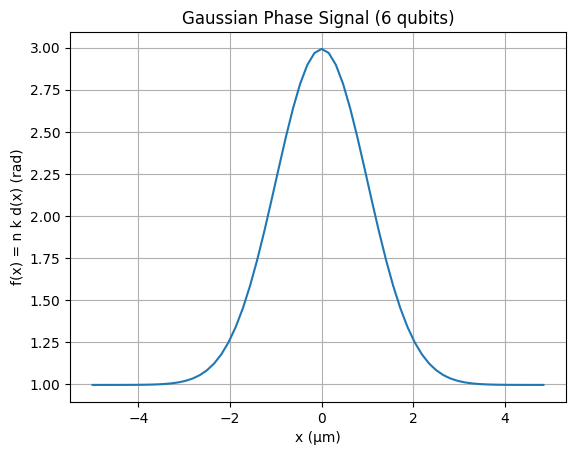


Running for 7 qubits (Nx = 128)


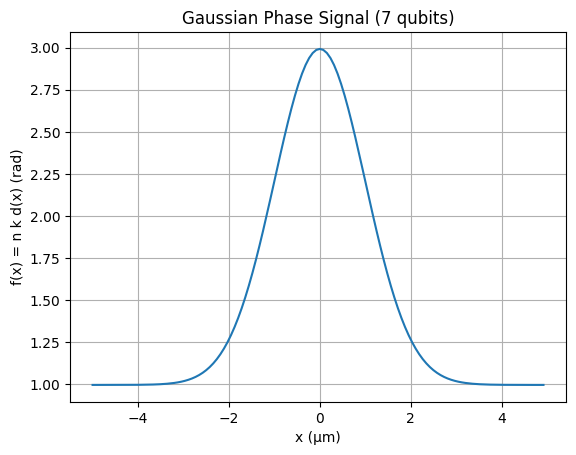


Running for 8 qubits (Nx = 256)


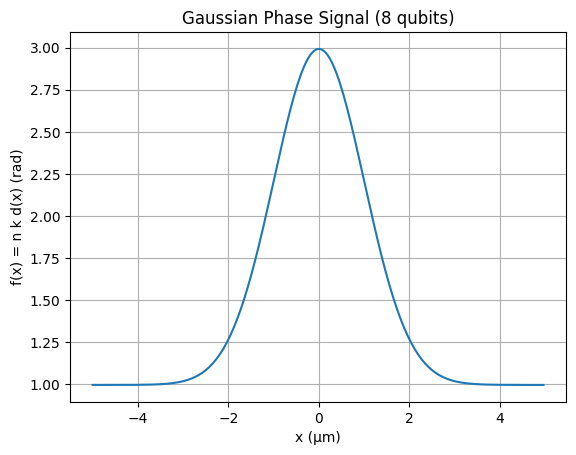


Running for 9 qubits (Nx = 512)


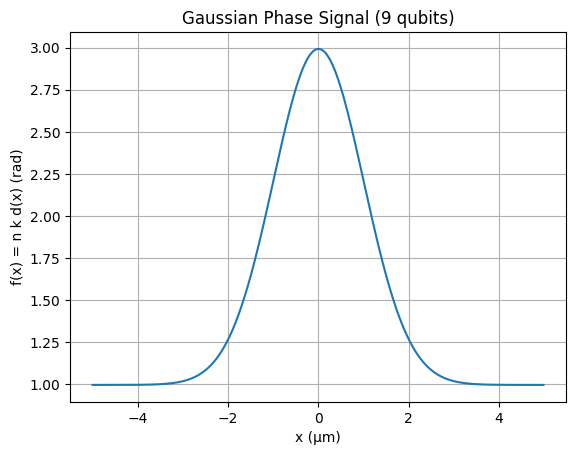

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_grid(L, Nx):
    return np.linspace(-L/2, L/2, Nx, endpoint=False)

def gaussian_thickness_profile(x, d0, h, sigma, x0=0):
    return d0 + h * np.exp(-((x - x0)**2) / (2 * sigma**2))

def phase_signal(d, n, lam):
    k = 2*np.pi / lam
    return n * k * d

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

def plot_signal(x, f, n_qubits):
    plt.figure()
    plt.plot(x * 1e6, f)
    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title(f"Gaussian Phase Signal ({n_qubits} qubits)")
    plt.grid(True)
    plt.show()

# spatial parameters
T = 10e-6

# optical parameters
lam = 630e-9
n_refr = 1.0

# Gaussian parameters
d0 = 100e-9
h = 200e-9
sigma = 1e-6
x0 = 0.0  # controls width

for n_qubits in range(6, 10):
    Nx = 2**n_qubits

    print(f"\nRunning for {n_qubits} qubits (Nx = {Nx})")

    x = spatial_grid(T, Nx)

    d = gaussian_thickness_profile(x, d0, h, sigma)

    f = phase_signal(d, n_refr, lam)

    phi, alpha = phi_from_f(f)

    plot_signal(x, f, n_qubits)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity

# simulator
sim = AerSimulator(method="statevector")

qubit_range = range(6, 11)
layer_range = range(50, 701, 50)

# store fidelity matrix
fidelity_map = np.zeros((len(layer_range), len(qubit_range)))

for qi, n_qubits in enumerate(qubit_range):

    Nx = 2**n_qubits

    # --- regenerate your phi here ---
    x = spatial_grid(T, Nx)
    d = gaussian_thickness_profile(x, x0, sigma, d0, h)
    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    print(f"\nRunning for {n_qubits} qubits")

    for li, L in enumerate(layer_range):

        # MPS initializer
        phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
        U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

        qc = QuantumCircuit(n_qubits)
        qc.append(U_phi, range(n_qubits))
        qc.save_statevector()

        result = sim.run(transpile(qc, sim)).result()
        vec_sim = np.array(result.get_statevector(qc), dtype=complex)

        # fidelity
        F = state_fidelity(vec_sim, phi)

        fidelity_map[li, qi] = F


Running for 6 qubits

Running for 7 qubits

Running for 8 qubits

Running for 9 qubits

Running for 10 qubits


In [3]:
import numpy as np
import matplotlib.pyplot as plt

best_layers = []
best_fidelities = []

for qi in range(len(qubit_range)):
    fidelities = fidelity_map[:, qi]

    best_idx = np.argmax(fidelities)          # index of maximum fidelity
    best_layer = layer_range[best_idx]        # corresponding layer
    best_fidelity = fidelities[best_idx]

    best_layers.append(best_layer)
    best_fidelities.append(best_fidelity)

    print(f"Qubits = {qubit_range[qi]}, Best layer = {best_layer}, Max fidelity = {best_fidelity:.8f}")

Qubits = 6, Best layer = 50, Max fidelity = 1.00000000
Qubits = 7, Best layer = 350, Max fidelity = 1.00000000
Qubits = 8, Best layer = 250, Max fidelity = 1.00000000
Qubits = 9, Best layer = 700, Max fidelity = 1.00000000
Qubits = 10, Best layer = 600, Max fidelity = 0.99999988


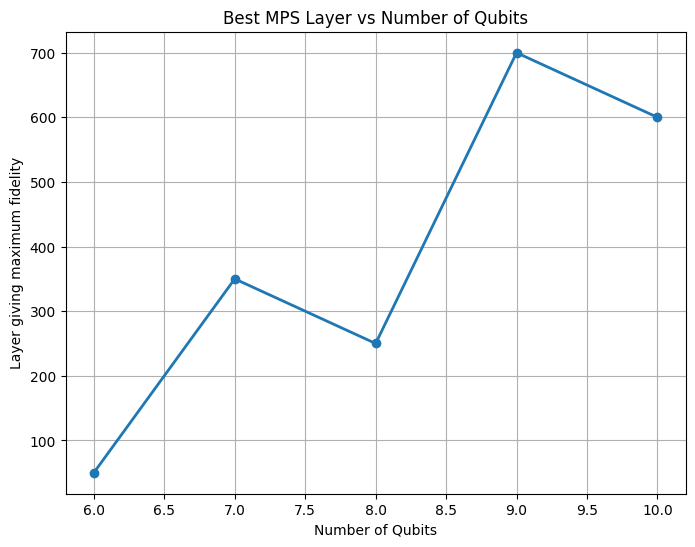

In [4]:
plt.figure(figsize=(8, 6))
plt.plot(qubit_range, best_layers, 'o-', linewidth=2)

plt.xlabel("Number of Qubits")
plt.ylabel("Layer giving maximum fidelity")
plt.title("Best MPS Layer vs Number of Qubits")
plt.grid(True)
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

threshold = 0.99

layers_needed = []
fidelities_at_threshold = []

for qi in range(len(qubit_range)):
    fidelities = fidelity_map[:, qi]

    idx = np.where(fidelities >= threshold)[0]   # all layer indices reaching threshold

    if len(idx) > 0:
        first_idx = idx[0]                       # first layer reaching threshold
        chosen_layer = layer_range[first_idx]
        chosen_fidelity = fidelities[first_idx]
    else:
        chosen_layer = np.nan
        chosen_fidelity = np.nan

    layers_needed.append(chosen_layer)
    fidelities_at_threshold.append(chosen_fidelity)

    print(f"Qubits = {qubit_range[qi]}, Layer = {chosen_layer}, Fidelity = {chosen_fidelity}")

Qubits = 6, Layer = 50, Fidelity = 0.999999999951573
Qubits = 7, Layer = 50, Fidelity = 0.9999975593251016
Qubits = 8, Layer = 50, Fidelity = 0.9954587651063526
Qubits = 9, Layer = 250, Fidelity = 0.9999883288393715
Qubits = 10, Layer = 300, Fidelity = 0.9985097771046387


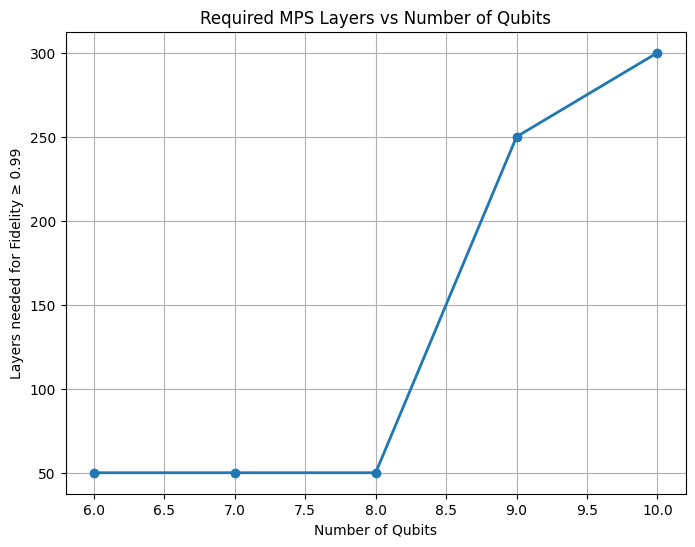

In [6]:
plt.figure(figsize=(8, 6))
plt.plot(qubit_range, layers_needed, 'o-', linewidth=2)

plt.xlabel("Number of Qubits")
plt.ylabel(f"Layers needed for Fidelity ≥ {threshold}")
plt.title("Required MPS Layers vs Number of Qubits")
plt.grid(True)
plt.show()

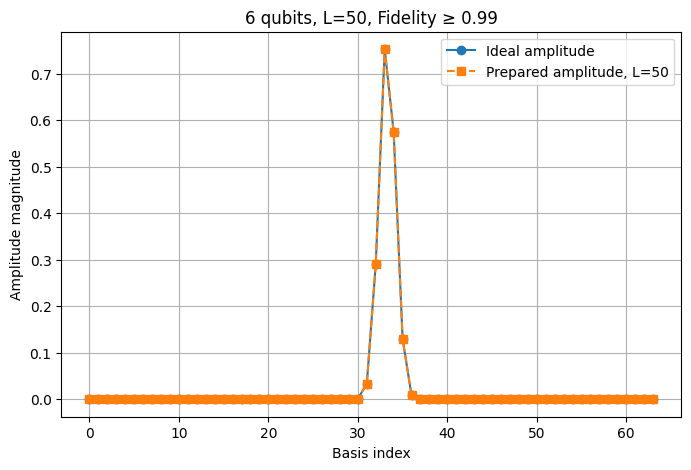

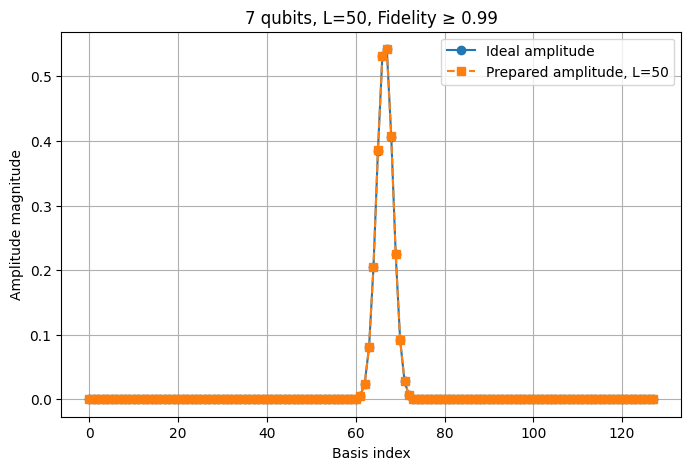

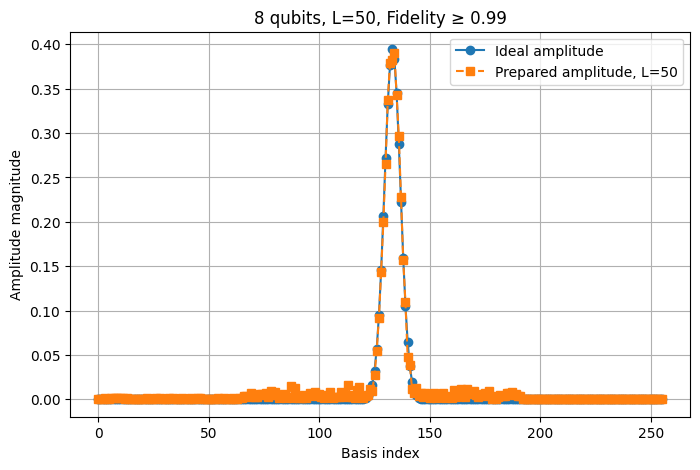

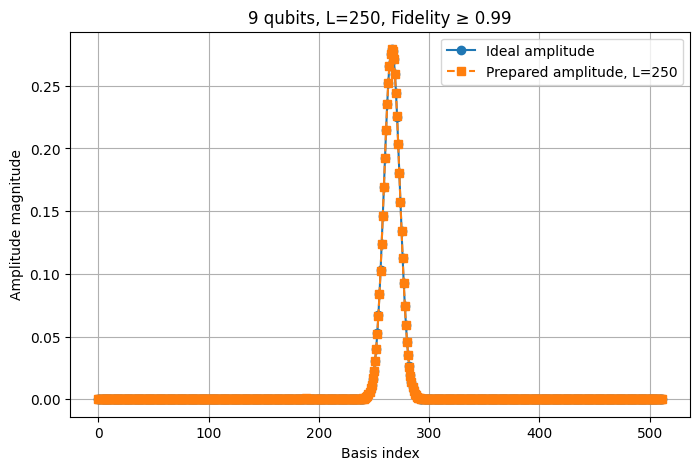

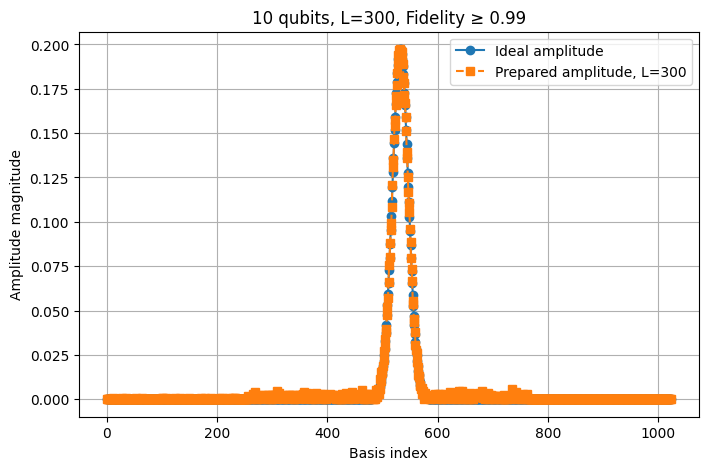

In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState

sim = AerSimulator(method="statevector")

for qi, n_qubits in enumerate(qubit_range):
    chosen_layer = layers_needed[qi]

    if np.isnan(chosen_layer):
        print(f"{n_qubits} qubits: fidelity {threshold} not reached.")
        continue

    Nx = 2**n_qubits

    # regenerate phi for this qubit count
    x = spatial_grid(T, Nx)
    d = gaussian_thickness_profile(x, x0, sigma, d0, h)
    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    # build threshold-layer circuit
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=int(chosen_layer))

    qc = QuantumCircuit(n_qubits)
    qc.append(U_phi, range(n_qubits))
    qc.save_statevector()

    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # align global phase
    global_phase = np.angle(np.vdot(phi, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    amps_ideal = np.abs(phi)
    amps_sim = np.abs(vec_sim_aligned)

    plt.figure(figsize=(8, 5))
    plt.plot(range(Nx), amps_ideal, 'o-', label="Ideal amplitude")
    plt.plot(range(Nx), amps_sim, 's--', label=f"Prepared amplitude, L={int(chosen_layer)}")
    plt.xlabel("Basis index")
    plt.ylabel("Amplitude magnitude")
    plt.title(f"{n_qubits} qubits, L={int(chosen_layer)}, Fidelity ≥ {threshold}")
    plt.legend()
    plt.grid(True)
    plt.show()